# 7_EDA_2 — 타겟변수 중심 시각화
### 성수 작성

---

## 탐색적 데이터 분석 (EDA 2번 담당)

**목표**: `apt_ml_master.csv` 에서 타겟변수(`dealAmount_num`) 의 분포와 **모든 주요 변수**와의 관계를 시각적으로 파악

### 분석 단계
1. 타겟변수 시각화 — `dealAmount_num` 분포·왜도·이상치
2. 타겟변수 vs 수치형 변수 상관관계 — 전체 히트맵 + 개별 산점도
3. 타겟변수 vs 시간 변수 — 연도·월별 가격 패턴
4. 타겟변수 vs 건물 특성 변수 — 면적·층·건축연도·지하여부
5. 타겟변수 vs 범주형 변수 — 클러스터·거래유형·임차권
6. 타겟변수 vs 커스텀 피처 — 야간광·고령화율 유의성 검증
7. 커스텀 피처 상관계수 종합 비교

---

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from matplotlib.lines import Line2D

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 클러스터 색상 (AGENTS.md 기준)
CLUSTER_COLOR = {'고광도': '#e63946', '중광도': '#f4a261', '저광도': '#457b9d'}
CLUSTER_ORDER = ['고광도', '중광도', '저광도']

np.random.seed(42)

print('라이브러리 로드 완료')
print(f'Pandas 버전: {pd.__version__}')
print(f'Numpy 버전: {np.__version__}')

라이브러리 로드 완료
Pandas 버전: 2.3.3
Numpy 버전: 2.2.5


---

# 0. 데이터 로드 및 기본 정보

**데이터 로드** (`6_preprocessing_apt.ipynb`에서 만든 파일)

In [2]:
df = pd.read_csv('apt_ml_master.csv', low_memory=False)

print('데이터셋 기본 정보')
print(f'총 레코드 수: {len(df):,}건')
print(f'총 컬럼 수: {len(df.columns)}개')
print(f'\n결측치 현황:')
print(df.isnull().sum()[df.isnull().sum() > 0])

데이터셋 기본 정보
총 레코드 수: 2,396,830건
총 컬럼 수: 46개

결측치 현황:
aptDong    25
고령화율       93
dtype: int64


In [3]:
# 분석용 컬럼 정의
NUM_COLS = ['excluUseAr_num', 'floor_num', 'buildYear',
            'nightlight_avg', '고령화율',
            'nl_2019', 'nl_2020', 'nl_2021', 'nl_2022', 'nl_2023']

TIME_COLS  = ['dealYear', 'dealMonth']
CAT_COLS   = ['cluster_name', 'landLeaseholdGbn']
TARGET     = 'dealAmount_num'

# 시각화용 샘플 (3만)
sample = df.sample(30000, random_state=42)

print('분석 준비 완료')
print(f'수치형 피처: {NUM_COLS}')
print(f'시간 피처: {TIME_COLS}')
print(f'범주형 피처: {CAT_COLS}')

분석 준비 완료
수치형 피처: ['excluUseAr_num', 'floor_num', 'buildYear', 'nightlight_avg', '고령화율', 'nl_2019', 'nl_2020', 'nl_2021', 'nl_2022', 'nl_2023']
시간 피처: ['dealYear', 'dealMonth']
범주형 피처: ['cluster_name', 'landLeaseholdGbn']


In [4]:
# 기술 통계
df[[TARGET] + NUM_COLS].describe()

,dealAmount_num,excluUseAr_num,floor_num,buildYear,nightlight_avg,고령화율,nl_2019,nl_2020,nl_2021,nl_2022,nl_2023
count,2.396830e+06,2.396830e+06,2.396830e+06,2.396830e+06,2.396830e+06,2.396737e+06,2.396830e+06,2.396830e+06,2.396830e+06,2.396830e+06,2.396830e+06
mean,3.506755e+04,7.419759e+01,9.391514e+00,2.002808e+03,3.155122e+01,1.557264e+01,2.898499e+01,2.920650e+01,3.008122e+01,3.195063e+01,3.155122e+01
std,3.522020e+04,2.517293e+01,6.508067e+00,1.007204e+01,1.715612e+01,4.886279e+00,1.600556e+01,1.595326e+01,1.602971e+01,1.701203e+01,1.715612e+01
min,4.000000e+02,9.260000e+00,-3.000000e+00,1.961000e+03,7.175000e-01,6.580000e+00,4.437000e-01,4.825000e-01,5.367000e-01,6.683000e-01,7.175000e-01
25%,1.490000e+04,5.971690e+01,4.000000e+00,1.995000e+03,1.877822e+01,1.242000e+01,1.780817e+01,1.836464e+01,1.850867e+01,1.926054e+01,1.877822e+01
50%,2.550000e+04,7.491000e+01,8.000000e+00,2.002000e+03,3.017281e+01,1.473000e+01,2.766725e+01,2.764910e+01,2.925783e+01,3.073459e+01,3.017281e+01
75%,4.300000e+04,8.495000e+01,1.300000e+01,2.011000e+03,4.049388e+01,1.789000e+01,3.734824e+01,3.798469e+01,3.789099e+01,3.943936e+01,4.049388e+01
max,1.800000e+06,3.173600e+02,8.300000e+01,2.025000e+03,1.162118e+02,4.488000e+01,1.170904e+02,1.164735e+02,1.090335e+02,1.100292e+02,1.162118e+02


In [5]:
df[['aptNm', 'SGG_NM', 'dealYear', 'dealMonth', TARGET,
    'excluUseAr_num', 'floor_num', 'buildYear',
    'cluster_name', 'nightlight_avg', '고령화율']].head(10)

,aptNm,SGG_NM,dealYear,dealMonth,dealAmount_num,excluUseAr_num,floor_num,buildYear,cluster_name,nightlight_avg,고령화율
0,광화문스페이스본(101동~105동),종로구,2019,1,119000.0,147.310,1.0,2008,고광도,61.153505,16.94
1,벽산블루밍평창힐스,종로구,2019,1,99000.0,150.940,3.0,2004,고광도,61.153505,16.94
2,동대문,종로구,2019,1,29000.0,28.800,3.0,1966,고광도,61.153505,16.94
3,롯데낙천대,종로구,2019,1,57500.0,84.210,5.0,2001,고광도,61.153505,16.94
4,삼성,종로구,2019,1,35500.0,59.970,11.0,1998,고광도,61.153505,16.94
5,익성씨티하임,종로구,2019,1,11000.0,14.480,10.0,2013,고광도,61.153505,16.94
6,익성씨티하임,종로구,2019,1,11300.0,15.760,10.0,2013,고광도,61.153505,16.94
7,익성씨티하임,종로구,2019,1,11000.0,15.420,10.0,2013,고광도,61.153505,16.94
8,광화문스페이스본(101동~105동),종로구,2019,1,119000.0,131.440,13.0,2008,고광도,61.153505,16.94
9,포레스트힐시티,종로구,2019,1,20500.0,16.672,10.0,2017,고광도,61.153505,16.94


---

# 1. 타겟변수 시각화

**`dealAmount_num` (단위: 만원) 의 분포·왜도·이상치를 전반적으로 파악.**

## 1.1 기술 통계 요약

In [6]:
print('=== 타겟변수 (dealAmount_num) 기술 통계 ===')
print(df[TARGET].describe())

print(f'\n중앙값: {df[TARGET].median()/10000:.2f}억원')
print(f'평균  : {df[TARGET].mean()/10000:.2f}억원')
print(f'왜도  : {df[TARGET].skew():.2f}  → 양수면 우편향 (log 변환 권장)')
print(f'첨도  : {df[TARGET].kurt():.2f}')

p_vals = [1, 5, 25, 50, 75, 95, 99]
print('\n백분위수 (억원):')
for p in p_vals:
    print(f'  {p:>3}%: {df[TARGET].quantile(p/100)/10000:.2f}억')

=== 타겟변수 (dealAmount_num) 기술 통계 ===
count    2.396830e+06
mean     3.506755e+04
std      3.522020e+04
min      4.000000e+02
25%      1.490000e+04
50%      2.550000e+04
75%      4.300000e+04
max      1.800000e+06
Name: dealAmount_num, dtype: float64

중앙값: 2.55억원
평균  : 3.51억원
왜도  : 4.42  → 양수면 우편향 (log 변환 권장)
첨도  : 45.19

백분위수 (억원):
    1%: 0.34억
    5%: 0.62억
   25%: 1.49억
   50%: 2.55억
   75%: 4.30억
   95%: 9.35억
   99%: 17.45억


## 1.2 분포 히스토그램 — 원본 vs log 변환

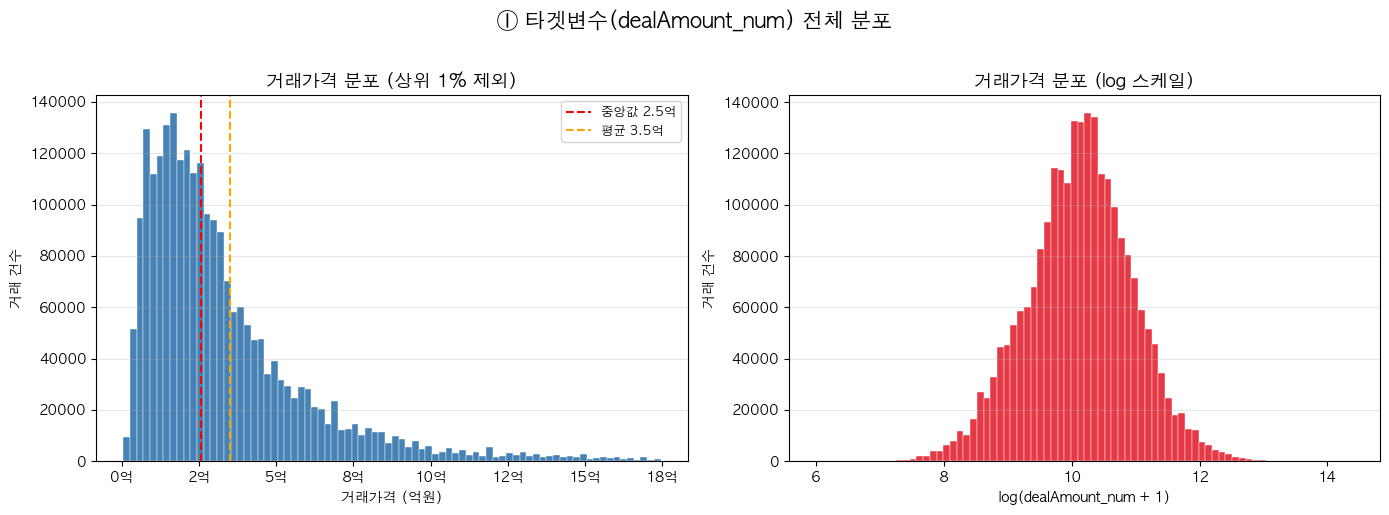

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 (상위 1% 제외)
p99 = df[TARGET].quantile(0.99)
data_trim = df.loc[df[TARGET] <= p99, TARGET]

axes[0].hist(data_trim / 10000, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(df[TARGET].median()/10000, color='red', linestyle='--', linewidth=1.5, label=f'중앙값 {df[TARGET].median()/10000:.1f}억')
axes[0].axvline(df[TARGET].mean()/10000,   color='orange', linestyle='--', linewidth=1.5, label=f'평균 {df[TARGET].mean()/10000:.1f}억')
axes[0].set_title('거래가격 분포 (상위 1% 제외)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('거래가격 (억원)')
axes[0].set_ylabel('거래 건수')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}억'))
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# log 스케일
log_data = np.log1p(df[TARGET])
axes[1].hist(log_data, bins=80, color='#e63946', edgecolor='white', linewidth=0.3)
axes[1].set_title('거래가격 분포 (log 스케일)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(dealAmount_num + 1)')
axes[1].set_ylabel('거래 건수')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('① 타겟변수(dealAmount_num) 전체 분포', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 클러스터별 거래건수 & 거래가격 (Act 2-5 핵심)

In [8]:
cluster_stat = df.groupby('cluster_name').agg(
    거래건수    =(TARGET, 'count'),
    평균가격    =(TARGET, 'mean'),
    중앙값가격  =(TARGET, 'median'),
    평균고령화율=('고령화율', 'mean'),
    평균야간광  =('nightlight_avg', 'mean')
).loc[CLUSTER_ORDER]
cluster_stat['평균가격_억']   = cluster_stat['평균가격']   / 10000
cluster_stat['중앙값가격_억'] = cluster_stat['중앙값가격'] / 10000

print('=== 클러스터별 요약 통계 (Act 2-5 발표 표) ===')
print(cluster_stat[['거래건수','평균가격_억','중앙값가격_억','평균고령화율','평균야간광']].to_string())

=== 클러스터별 요약 통계 (Act 2-5 발표 표) ===
                 거래건수    평균가격_억  중앙값가격_억     평균고령화율      평균야간광
cluster_name                                                  
고광도            273943  6.476213     4.48  15.187173  62.165560
중광도            869528  4.295540     3.40  14.657688  38.921464
저광도           1253359  2.310504     1.95  16.291692  19.746769


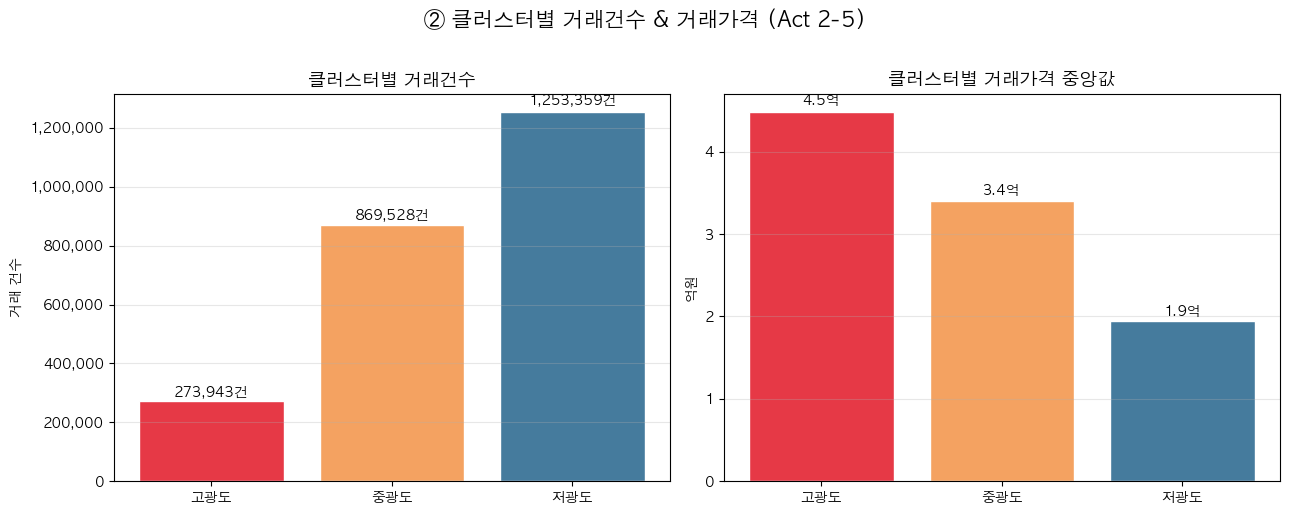

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = [CLUSTER_COLOR[c] for c in CLUSTER_ORDER]

bars0 = axes[0].bar(CLUSTER_ORDER, cluster_stat['거래건수'], color=colors, edgecolor='white')
axes[0].set_title('클러스터별 거래건수', fontsize=13, fontweight='bold')
axes[0].set_ylabel('거래 건수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars0:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{int(bar.get_height()):,}건', ha='center', va='bottom', fontsize=10)

bars1 = axes[1].bar(CLUSTER_ORDER, cluster_stat['중앙값가격_억'], color=colors, edgecolor='white')
axes[1].set_title('클러스터별 거래가격 중앙값', fontsize=13, fontweight='bold')
axes[1].set_ylabel('억원')
for bar in bars1:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{bar.get_height():.1f}억', ha='center', va='bottom', fontsize=10)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('② 클러스터별 거래건수 & 거래가격 (Act 2-5)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig02_cluster_count_price.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 2. 타겟변수 vs 수치형 변수 — 전체 상관관계

**수치형 피처 전체를 한눈에 파악하고, 상관계수가 높은 순으로 확인.**

## 2.1 전체 수치형 피처 상관계수 히트맵

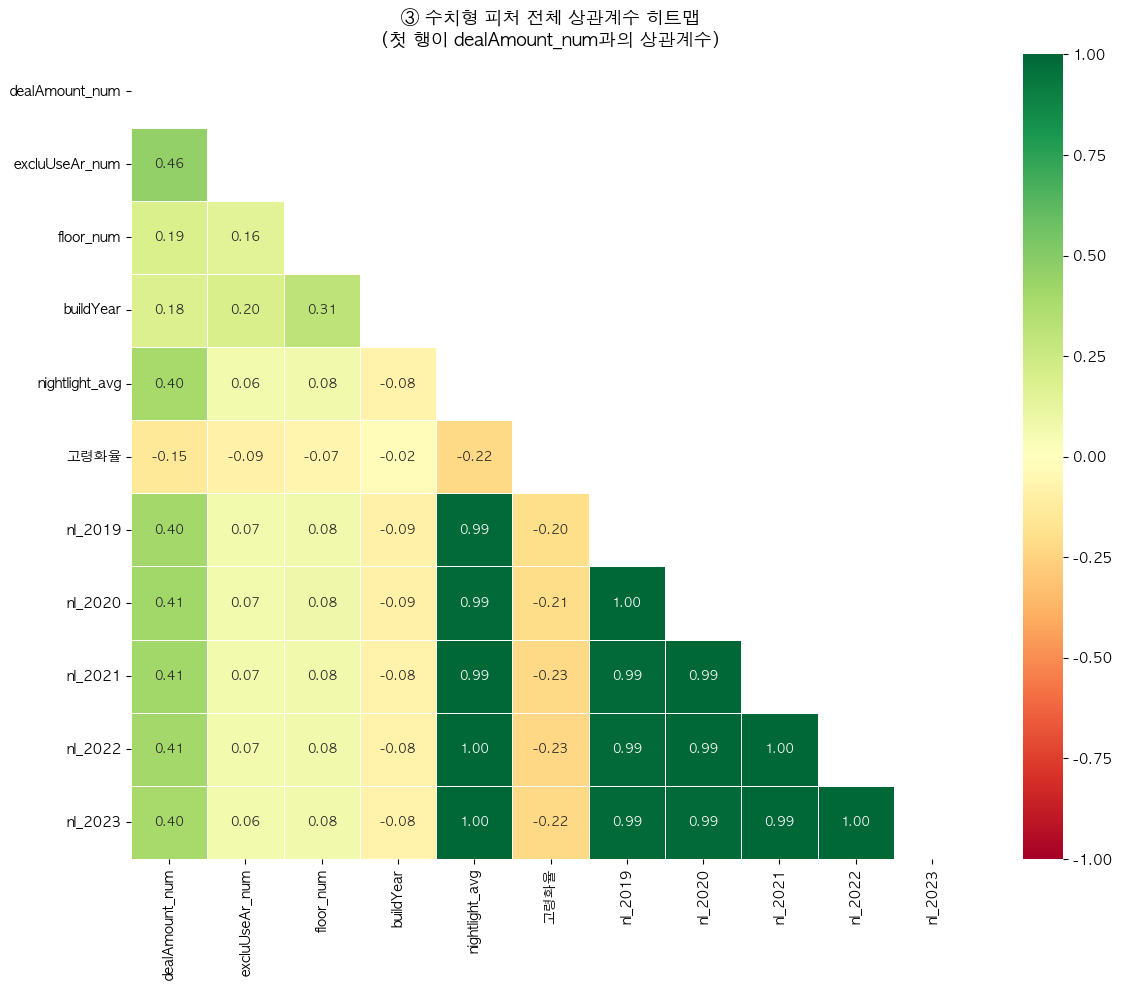


=== dealAmount_num 상관계수 (절댓값 내림차순) ===
excluUseAr_num    0.455770
nl_2020           0.409936
nl_2021           0.408076
nl_2022           0.405503
nl_2019           0.404145
nightlight_avg    0.396963
nl_2023           0.396963
floor_num         0.191761
buildYear         0.180213
고령화율              0.145462


In [10]:
all_num_cols = [TARGET] + NUM_COLS
corr = df[all_num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('③ 수치형 피처 전체 상관계수 히트맵\n(첫 행이 dealAmount_num과의 상관계수)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig03_corr_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== dealAmount_num 상관계수 (절댓값 내림차순) ===')
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).to_string())

## 2.2 타겟과의 상관계수 순위 바 차트

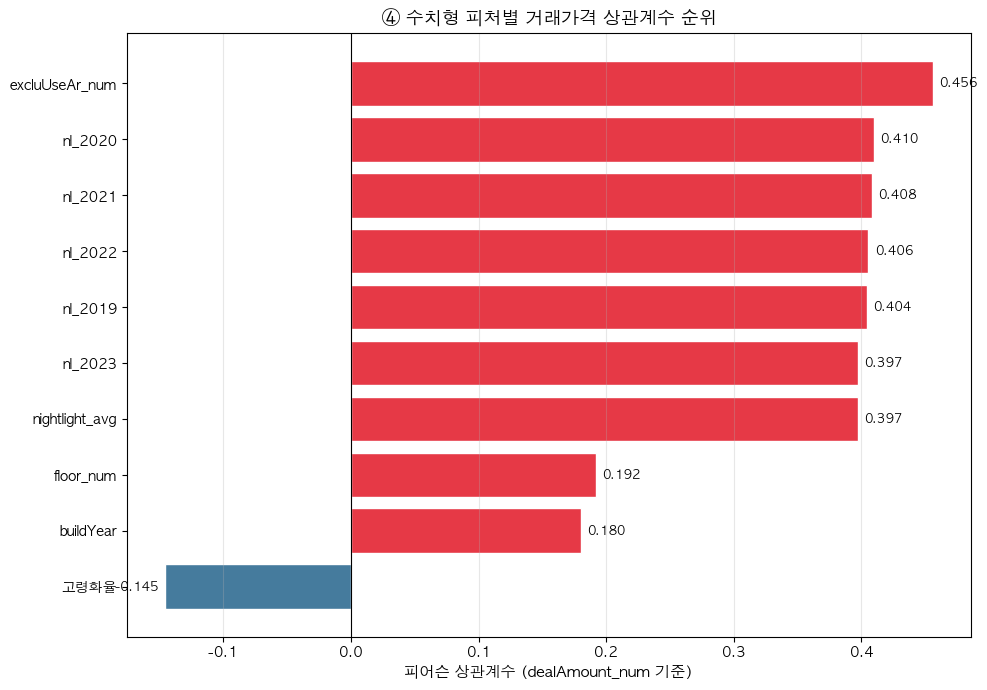

In [11]:
corr_rank = corr[TARGET].drop(TARGET).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#e63946' if v > 0 else '#457b9d' for v in corr_rank.values]
bars = ax.barh(corr_rank.index, corr_rank.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_rank.values):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('피어슨 상관계수 (dealAmount_num 기준)', fontsize=11)
ax.set_title('④ 수치형 피처별 거래가격 상관계수 순위', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig04_corr_rank_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 3. 타겟변수 vs 시간 변수

**거래 연도·월별 가격 패턴을 파악. 부동산 시장 흐름과 계절성을 확인.**

## 3.1 연도별 거래가격 추이 (전체 & 클러스터별)

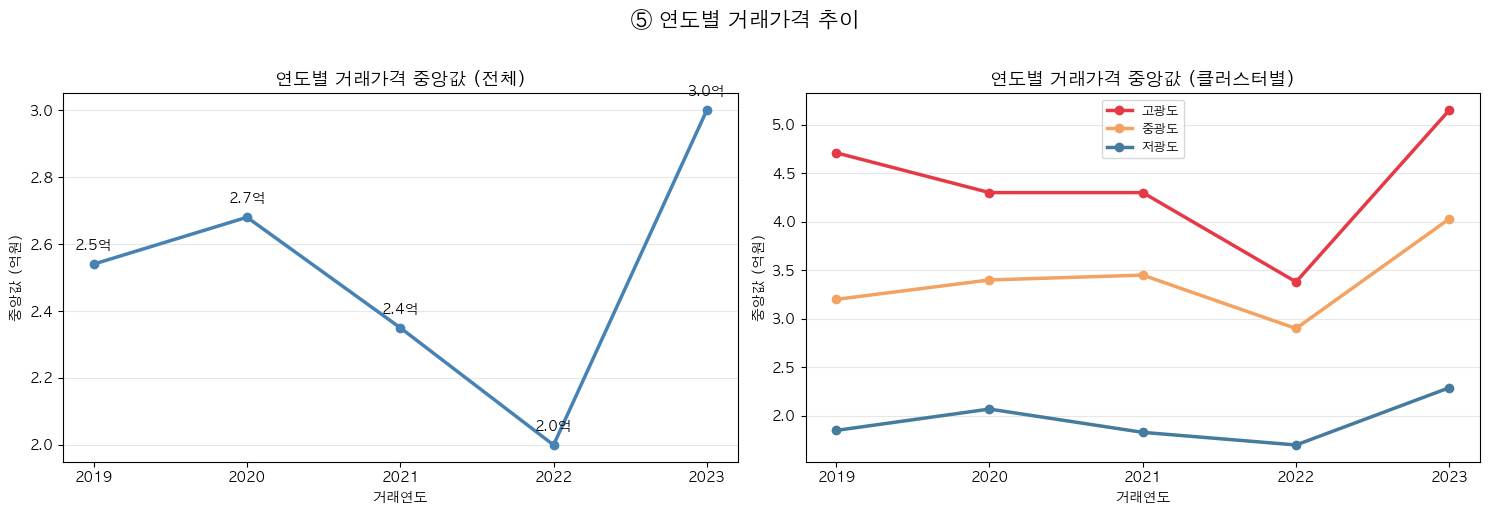

In [12]:
yearly_all = df.groupby('dealYear')[TARGET].median() / 10000
yearly_cl  = df.groupby(['dealYear','cluster_name'])[TARGET].median().unstack() / 10000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 전체 추이
axes[0].plot(yearly_all.index, yearly_all.values, marker='o', color='steelblue', linewidth=2.5)
for yr, val in yearly_all.items():
    axes[0].annotate(f'{val:.1f}억', (yr, val),
                     textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
axes[0].set_title('연도별 거래가격 중앙값 (전체)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('거래연도')
axes[0].set_ylabel('중앙값 (억원)')
axes[0].set_xticks(yearly_all.index)
axes[0].grid(axis='y', alpha=0.3)

# 클러스터별 추이
for c in CLUSTER_ORDER:
    if c in yearly_cl.columns:
        axes[1].plot(yearly_cl.index, yearly_cl[c], marker='o',
                     color=CLUSTER_COLOR[c], linewidth=2.5, label=c)
axes[1].set_title('연도별 거래가격 중앙값 (클러스터별)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('거래연도')
axes[1].set_ylabel('중앙값 (억원)')
axes[1].set_xticks(yearly_cl.index)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('⑤ 연도별 거래가격 추이', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig05_yearly_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 월별 거래가격 패턴 (계절성)

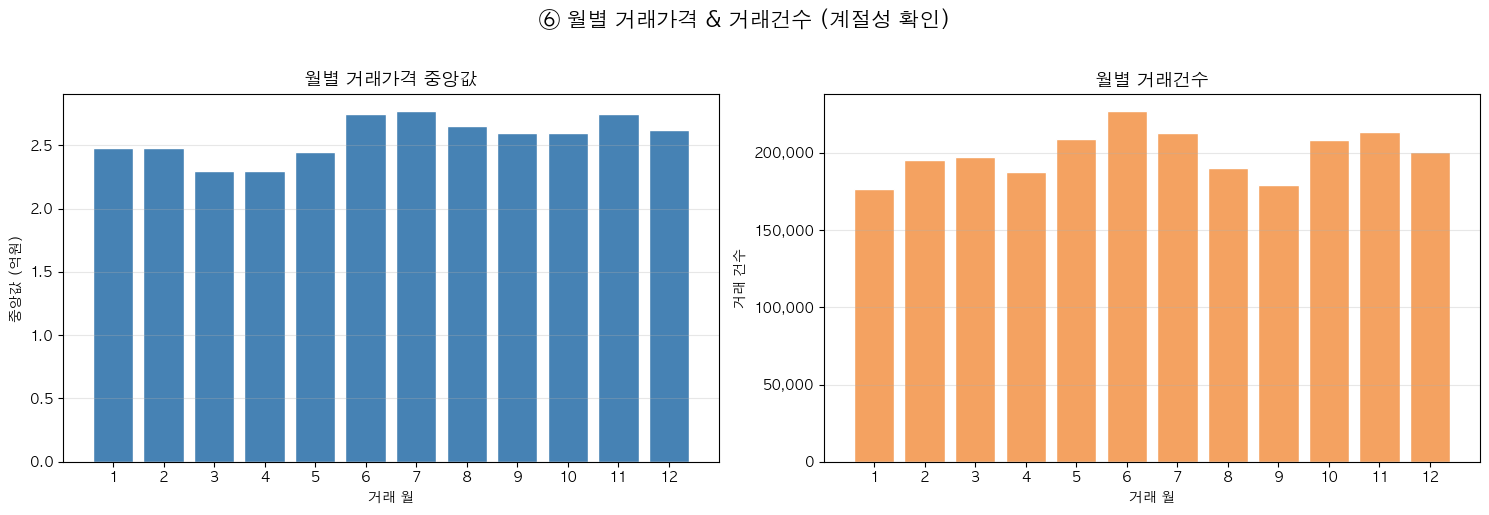

In [13]:
monthly_all = df.groupby('dealMonth')[TARGET].agg(['median','count'])
monthly_all['median_억'] = monthly_all['median'] / 10000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(monthly_all.index, monthly_all['median_억'], color='steelblue', edgecolor='white')
axes[0].set_title('월별 거래가격 중앙값', fontsize=13, fontweight='bold')
axes[0].set_xlabel('거래 월')
axes[0].set_ylabel('중앙값 (억원)')
axes[0].set_xticks(monthly_all.index)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(monthly_all.index, monthly_all['count'], color='#f4a261', edgecolor='white')
axes[1].set_title('월별 거래건수', fontsize=13, fontweight='bold')
axes[1].set_xlabel('거래 월')
axes[1].set_ylabel('거래 건수')
axes[1].set_xticks(monthly_all.index)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('⑥ 월별 거래가격 & 거래건수 (계절성 확인)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig06_monthly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 연도 × 클러스터 히트맵 — 가격 변화 패턴

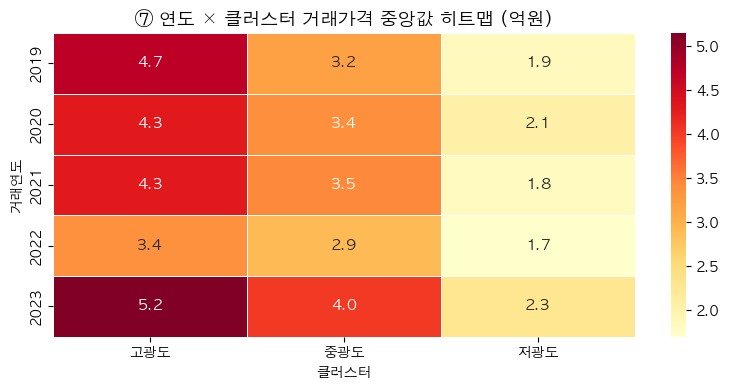

In [14]:
pivot = df.groupby(['dealYear','cluster_name'])[TARGET].median().unstack() / 10000
pivot = pivot[CLUSTER_ORDER]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, annot_kws={'size': 11})
ax.set_title('⑦ 연도 × 클러스터 거래가격 중앙값 히트맵 (억원)', fontsize=13, fontweight='bold')
ax.set_xlabel('클러스터')
ax.set_ylabel('거래연도')
plt.tight_layout()
plt.savefig('fig07_year_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 4. 타겟변수 vs 건물 특성 변수

**전용면적·층·건축연도·지하여부 등 건물 자체 속성과 거래가격의 관계를 파악.**

## 4.1 전용면적(excluUseAr_num) vs 거래가격

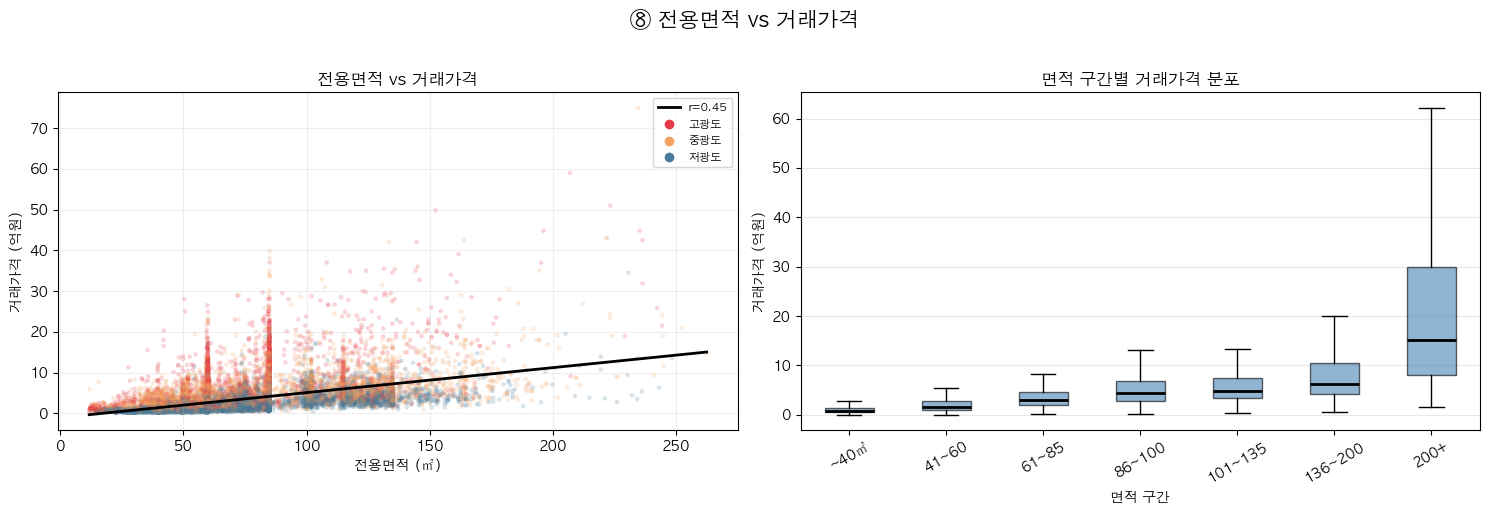

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 산점도
colors_s = [CLUSTER_COLOR[c] for c in sample['cluster_name']]
axes[0].scatter(sample['excluUseAr_num'], sample[TARGET]/10000,
                c=colors_s, alpha=0.15, s=6, rasterized=True)
clean = sample[['excluUseAr_num', TARGET]].dropna()
sl, ic, r, p, _ = stats.linregress(clean['excluUseAr_num'], clean[TARGET]/10000)
xr = np.linspace(clean['excluUseAr_num'].min(), clean['excluUseAr_num'].max(), 200)
axes[0].plot(xr, sl*xr+ic, color='black', linewidth=2, label=f'r={r:.2f}')
axes[0].set_xlabel('전용면적 (㎡)')
axes[0].set_ylabel('거래가격 (억원)')
axes[0].set_title('전용면적 vs 거래가격', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.2)

# 면적 구간별 박스플롯
df['area_bin'] = pd.cut(df['excluUseAr_num'],
                         bins=[0,40,60,85,100,135,200,999],
                         labels=['~40㎡','41~60','61~85','86~100','101~135','136~200','200+'])
area_order = ['~40㎡','41~60','61~85','86~100','101~135','136~200','200+']
data_area = [df.loc[df['area_bin']==b, TARGET].dropna()/10000 for b in area_order]
bp = axes[1].boxplot(data_area, labels=area_order, patch_artist=True,
                     showfliers=False, medianprops=dict(color='black', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue'); patch.set_alpha(0.6)
axes[1].set_xlabel('면적 구간')
axes[1].set_ylabel('거래가격 (억원)')
axes[1].set_title('면적 구간별 거래가격 분포', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=v, markersize=8, label=k)
              for k, v in CLUSTER_COLOR.items()]
axes[0].legend(handles=[Line2D([0],[0], color='black', linewidth=2, label=f'r={r:.2f}')] + legend_els,
               fontsize=8)

fig.suptitle('⑧ 전용면적 vs 거래가격', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig08_area_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 층(floor_num) vs 거래가격

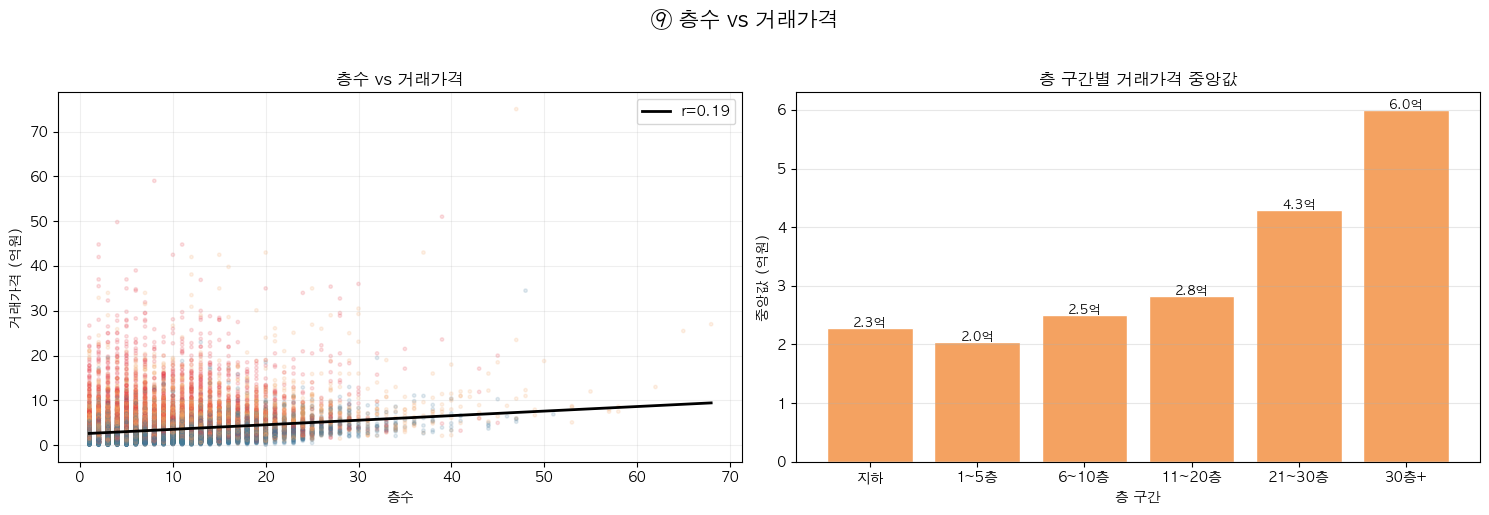

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 산점도
colors_s = [CLUSTER_COLOR[c] for c in sample['cluster_name']]
axes[0].scatter(sample['floor_num'], sample[TARGET]/10000,
                c=colors_s, alpha=0.15, s=6, rasterized=True)
clean = sample[['floor_num', TARGET]].dropna()
sl, ic, r, p, _ = stats.linregress(clean['floor_num'], clean[TARGET]/10000)
xr = np.linspace(clean['floor_num'].min(), clean['floor_num'].max(), 200)
axes[0].plot(xr, sl*xr+ic, color='black', linewidth=2, label=f'r={r:.2f}')
axes[0].set_xlabel('층수')
axes[0].set_ylabel('거래가격 (억원)')
axes[0].set_title('층수 vs 거래가격', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.2)

# 층 구간별 중앙값
df['floor_bin'] = pd.cut(df['floor_num'],
                          bins=[-99,0,5,10,20,30,99],
                          labels=['지하','1~5층','6~10층','11~20층','21~30층','30층+'])
floor_order = ['지하','1~5층','6~10층','11~20층','21~30층','30층+']
floor_med = df.groupby('floor_bin')[TARGET].median() / 10000
floor_med = floor_med.reindex(floor_order)

axes[1].bar(floor_order, floor_med.values, color='#f4a261', edgecolor='white')
for i, val in enumerate(floor_med.values):
    if not np.isnan(val):
        axes[1].text(i, val+0.02, f'{val:.1f}억', ha='center', fontsize=9)
axes[1].set_xlabel('층 구간')
axes[1].set_ylabel('중앙값 (억원)')
axes[1].set_title('층 구간별 거래가격 중앙값', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('⑨ 층수 vs 거래가격', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig09_floor_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 건축연도(buildYear) vs 거래가격

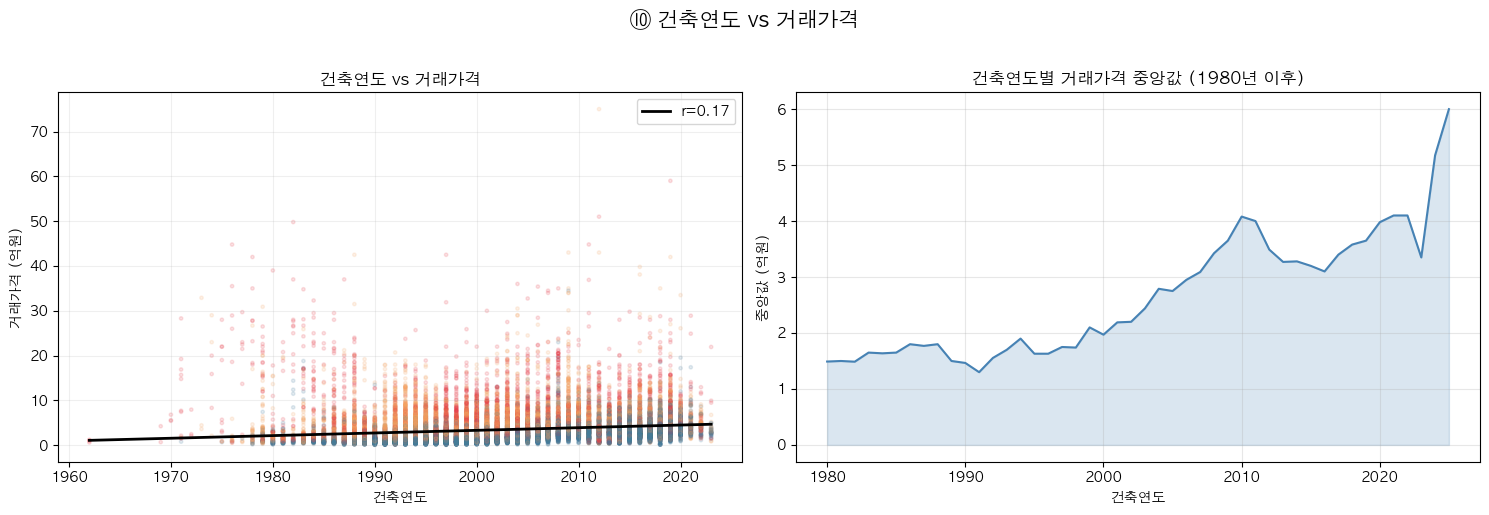

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 산점도
colors_s = [CLUSTER_COLOR[c] for c in sample['cluster_name']]
axes[0].scatter(sample['buildYear'], sample[TARGET]/10000,
                c=colors_s, alpha=0.15, s=6, rasterized=True)
clean = sample[['buildYear', TARGET]].dropna()
sl, ic, r, p, _ = stats.linregress(clean['buildYear'], clean[TARGET]/10000)
xr = np.linspace(clean['buildYear'].min(), clean['buildYear'].max(), 200)
axes[0].plot(xr, sl*xr+ic, color='black', linewidth=2, label=f'r={r:.2f}')
axes[0].set_xlabel('건축연도')
axes[0].set_ylabel('거래가격 (억원)')
axes[0].set_title('건축연도 vs 거래가격', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.2)

# 건축연도별 연평균 중앙값
year_med = df.groupby('buildYear')[TARGET].median() / 10000
year_med = year_med[year_med.index >= 1980]
axes[1].plot(year_med.index, year_med.values, color='steelblue', linewidth=1.5)
axes[1].fill_between(year_med.index, year_med.values, alpha=0.2, color='steelblue')
axes[1].set_xlabel('건축연도')
axes[1].set_ylabel('중앙값 (억원)')
axes[1].set_title('건축연도별 거래가격 중앙값 (1980년 이후)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

fig.suptitle('⑩ 건축연도 vs 거래가격', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_buildyear_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 건물 피처 3종 한눈에 — 클러스터 색상 산점도 비교

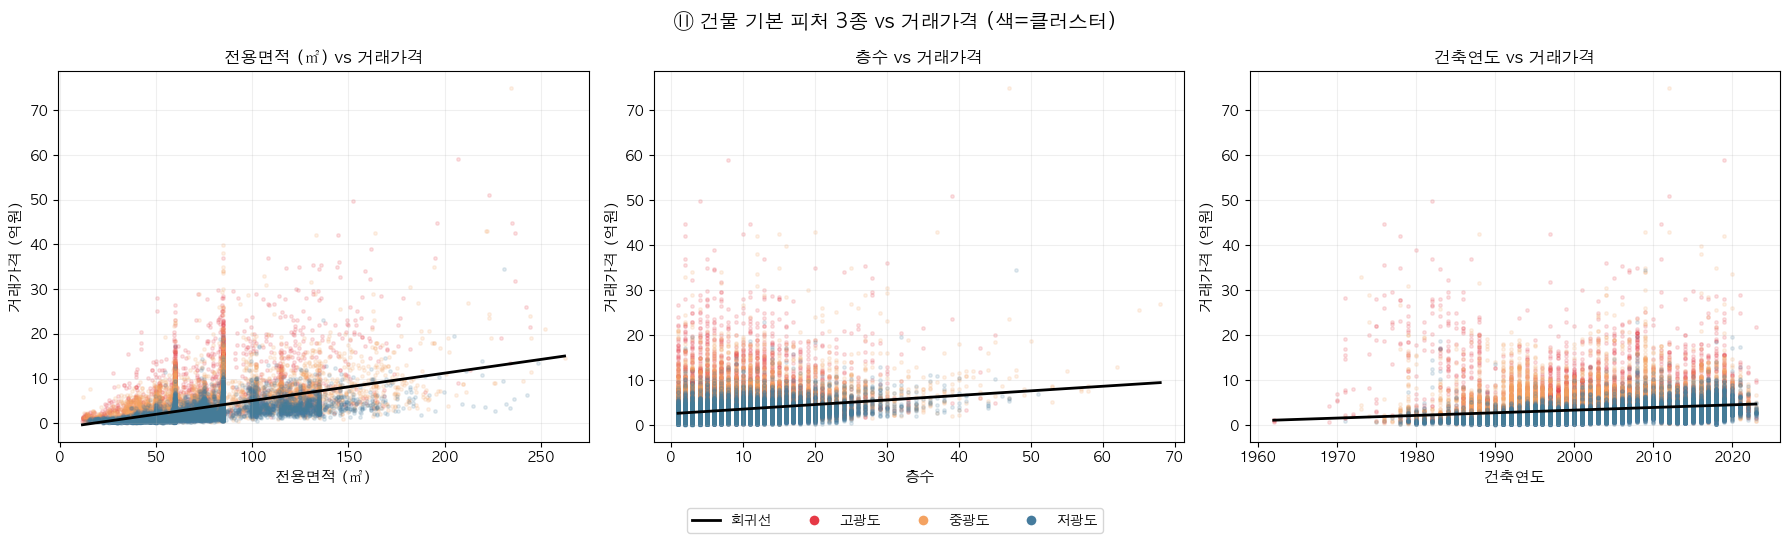

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    ('excluUseAr_num', '전용면적 (㎡)'),
    ('floor_num',      '층수'),
    ('buildYear',      '건축연도'),
]

for ax, (col, label) in zip(axes, pairs):
    for cl in CLUSTER_ORDER:
        sub = sample[sample['cluster_name'] == cl]
        ax.scatter(sub[col], sub[TARGET]/10000,
                   c=CLUSTER_COLOR[cl], label=cl, alpha=0.15, s=6, rasterized=True)
    clean = sample[[col, TARGET]].dropna()
    sl, ic, r, p, _ = stats.linregress(clean[col], clean[TARGET]/10000)
    xr = np.linspace(clean[col].min(), clean[col].max(), 200)
    ax.plot(xr, sl*xr+ic, color='black', linewidth=2, label=f'r={r:.2f}')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('거래가격 (억원)', fontsize=11)
    ax.set_title(f'{label} vs 거래가격', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.2)

legend_els = ([Line2D([0],[0], color='black', linewidth=2, label=f'회귀선')] +
              [Line2D([0],[0], marker='o', color='w', markerfacecolor=v, markersize=8, label=k)
               for k, v in CLUSTER_COLOR.items()])
fig.legend(handles=legend_els, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08), fontsize=10)

fig.suptitle('⑪ 건물 기본 피처 3종 vs 거래가격 (색=클러스터)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_building_features_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 클러스터별 박스플롯 (가격 분포)

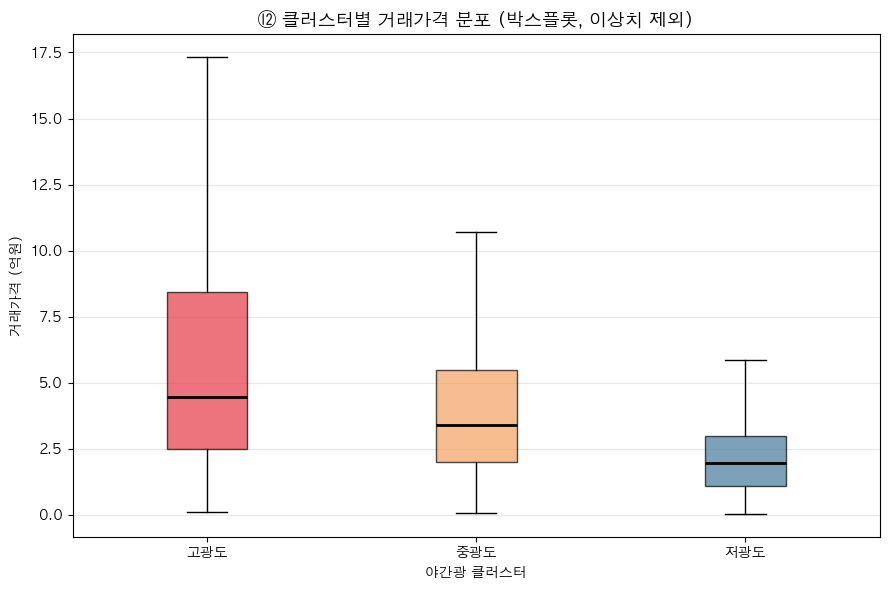

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

data_box = [df.loc[df['cluster_name']==c, TARGET].dropna()/10000 for c in CLUSTER_ORDER]
bp = ax.boxplot(data_box, labels=CLUSTER_ORDER, patch_artist=True,
                showfliers=False, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], CLUSTER_ORDER):
    patch.set_facecolor(CLUSTER_COLOR[c]); patch.set_alpha(0.7)

ax.set_title('⑫ 클러스터별 거래가격 분포 (박스플롯, 이상치 제외)', fontsize=13, fontweight='bold')
ax.set_ylabel('거래가격 (억원)')
ax.set_xlabel('야간광 클러스터')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig12_cluster_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 5. 타겟변수 vs 범주형 변수

**클러스터·임차권 유형 등 범주형 변수와 거래가격의 관계를 파악.**

## 5.1 임차권 유형(landLeaseholdGbn) vs 거래가격

=== 임차권 유형별 통계 ===
                    median    count  median_억
landLeaseholdGbn                             
N                  25500.0  2396685      2.55
Y                 100000.0      145     10.00


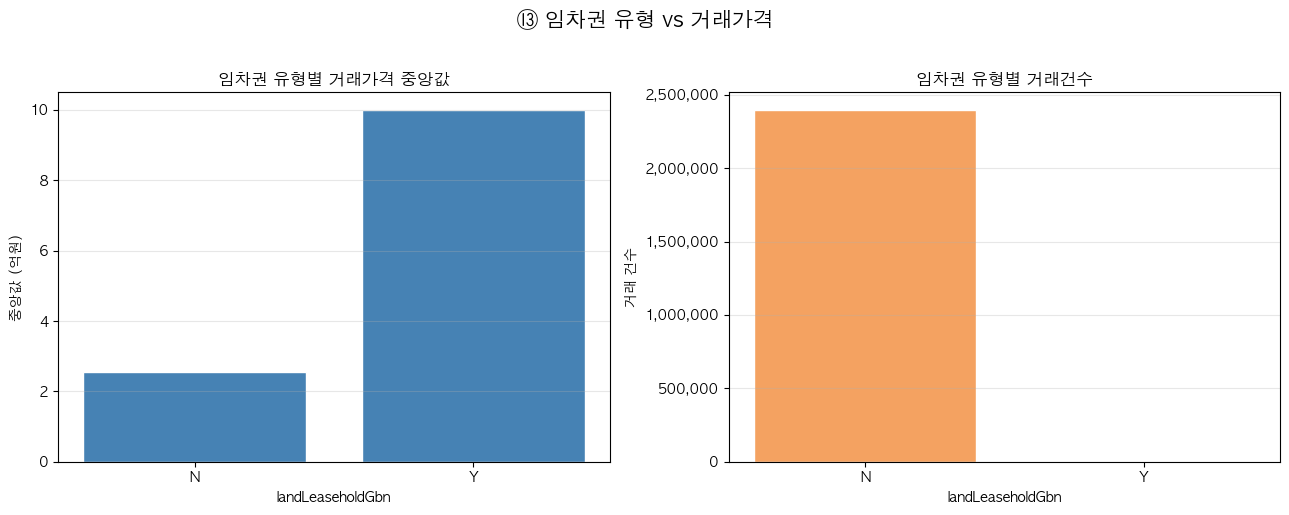

In [20]:
llg_stat = df.groupby('landLeaseholdGbn')[TARGET].agg(['median','count'])
llg_stat['median_억'] = llg_stat['median'] / 10000
print('=== 임차권 유형별 통계 ===')
print(llg_stat)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(llg_stat.index, llg_stat['median_억'], color='steelblue', edgecolor='white')
axes[0].set_title('임차권 유형별 거래가격 중앙값', fontsize=12, fontweight='bold')
axes[0].set_xlabel('landLeaseholdGbn')
axes[0].set_ylabel('중앙값 (억원)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(llg_stat.index, llg_stat['count'], color='#f4a261', edgecolor='white')
axes[1].set_title('임차권 유형별 거래건수', fontsize=12, fontweight='bold')
axes[1].set_xlabel('landLeaseholdGbn')
axes[1].set_ylabel('거래 건수')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('⑬ 임차권 유형 vs 거래가격', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig13_leasehold_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.2 시군구별 평균 거래가격 Top/Bottom 20

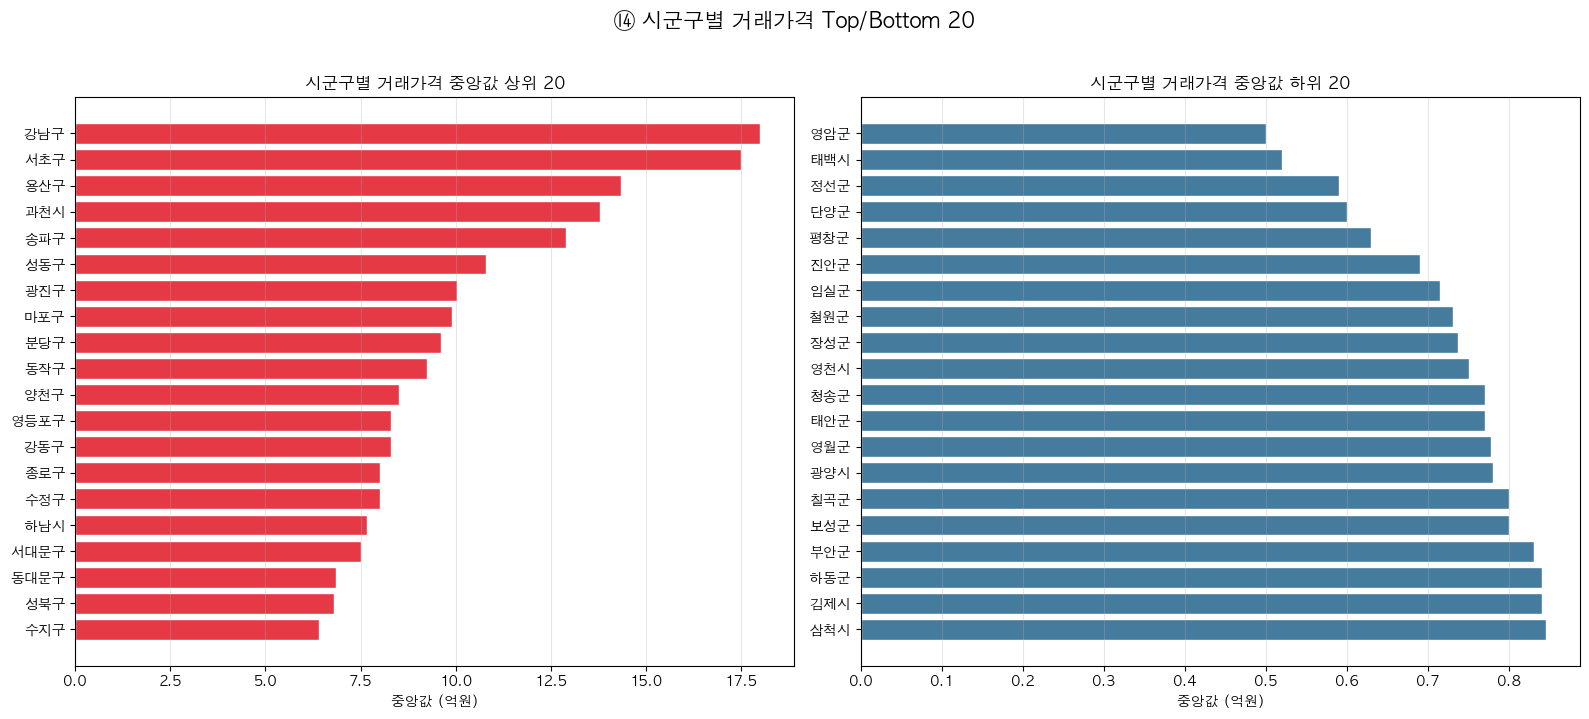

In [21]:
sgg_price = df.groupby('SGG_NM')[TARGET].median().sort_values(ascending=False) / 10000
top20  = sgg_price.head(20)
bot20  = sgg_price.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top20.index[::-1], top20.values[::-1], color='#e63946', edgecolor='white')
axes[0].set_title('시군구별 거래가격 중앙값 상위 20', fontsize=12, fontweight='bold')
axes[0].set_xlabel('중앙값 (억원)')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(bot20.index, bot20.values, color='#457b9d', edgecolor='white')
axes[1].set_title('시군구별 거래가격 중앙값 하위 20', fontsize=12, fontweight='bold')
axes[1].set_xlabel('중앙값 (억원)')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('⑭ 시군구별 거래가격 Top/Bottom 20', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig14_sgg_price_rank.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 6. 타겟변수 vs 커스텀 피처 (피처 유의성 검증)

**야간광·고령화율·클러스터**는 우리가 직접 merge한 피처.  
이 피처가 거래가격을 실제로 설명하는지 시각화와 통계 검정으로 확인.

## 6.1 야간광(nightlight_avg) vs 거래가격

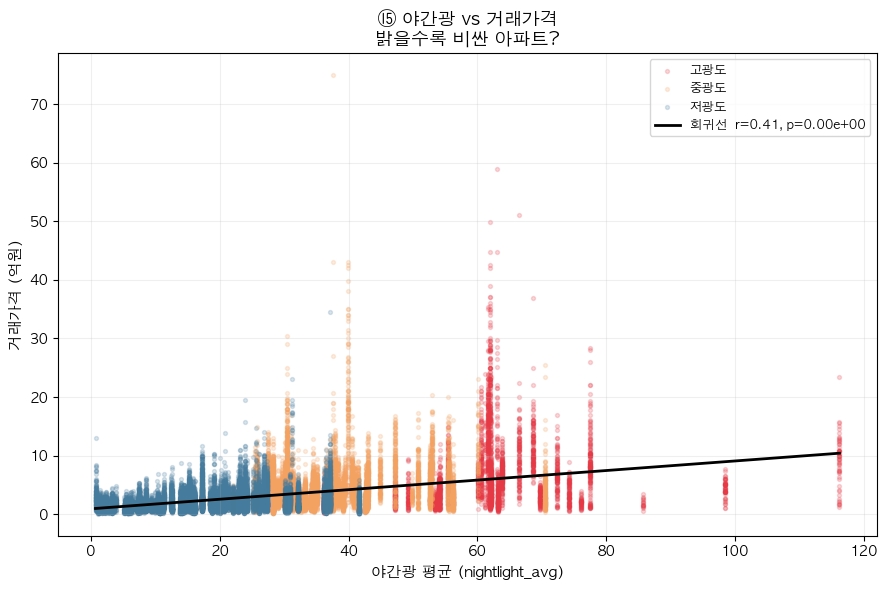

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))

for cluster in CLUSTER_ORDER:
    sub = sample[sample['cluster_name'] == cluster]
    ax.scatter(sub['nightlight_avg'], sub[TARGET]/10000,
               c=CLUSTER_COLOR[cluster], label=cluster, alpha=0.2, s=8, rasterized=True)

clean = sample[['nightlight_avg', TARGET]].dropna()
sl, ic, r, p, _ = stats.linregress(clean['nightlight_avg'], clean[TARGET]/10000)
xr = np.linspace(clean['nightlight_avg'].min(), clean['nightlight_avg'].max(), 300)
ax.plot(xr, sl*xr+ic, color='black', linewidth=2, label=f'회귀선  r={r:.2f}, p={p:.2e}')

ax.set_xlabel('야간광 평균 (nightlight_avg)', fontsize=11)
ax.set_ylabel('거래가격 (억원)', fontsize=11)
ax.set_title('⑮ 야간광 vs 거래가격\n밝을수록 비싼 아파트?', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig15_nightlight_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2 고령화율 vs 거래가격

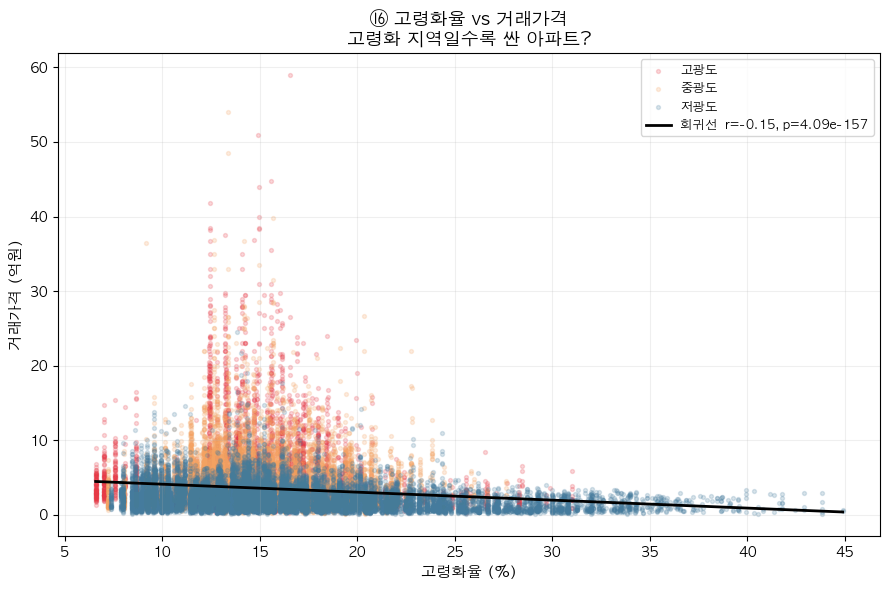

In [23]:
df_aging = df.dropna(subset=['고령화율'])
sample_aging = df_aging.sample(min(30000, len(df_aging)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

for cluster in CLUSTER_ORDER:
    sub = sample_aging[sample_aging['cluster_name'] == cluster]
    ax.scatter(sub['고령화율'], sub[TARGET]/10000,
               c=CLUSTER_COLOR[cluster], label=cluster, alpha=0.2, s=8, rasterized=True)

clean2 = sample_aging[['고령화율', TARGET]].dropna()
sl2, ic2, r2, p2, _ = stats.linregress(clean2['고령화율'], clean2[TARGET]/10000)
xr2 = np.linspace(clean2['고령화율'].min(), clean2['고령화율'].max(), 300)
ax.plot(xr2, sl2*xr2+ic2, color='black', linewidth=2, label=f'회귀선  r={r2:.2f}, p={p2:.2e}')

ax.set_xlabel('고령화율 (%)', fontsize=11)
ax.set_ylabel('거래가격 (억원)', fontsize=11)
ax.set_title('⑯ 고령화율 vs 거래가격\n고령화 지역일수록 싼 아파트?', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig16_aging_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 연도별 야간광(nl_2019~nl_2023) vs 거래가격

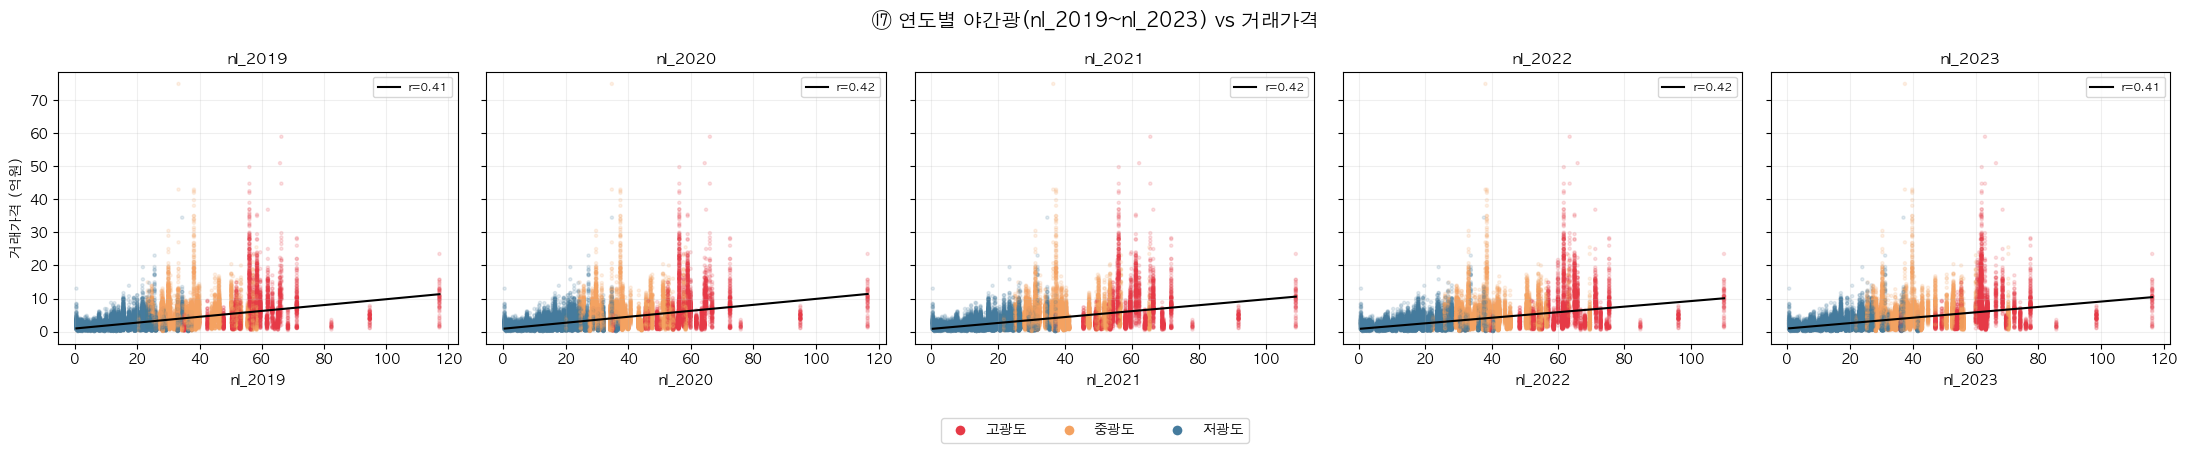

In [24]:
nl_cols = ['nl_2019', 'nl_2020', 'nl_2021', 'nl_2022', 'nl_2023']

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)

for ax, col in zip(axes, nl_cols):
    colors_s = [CLUSTER_COLOR[c] for c in sample['cluster_name']]
    ax.scatter(sample[col], sample[TARGET]/10000,
               c=colors_s, alpha=0.15, s=5, rasterized=True)
    clean = sample[[col, TARGET]].dropna()
    sl, ic, r, p, _ = stats.linregress(clean[col], clean[TARGET]/10000)
    xr = np.linspace(clean[col].min(), clean[col].max(), 200)
    ax.plot(xr, sl*xr+ic, color='black', linewidth=1.5, label=f'r={r:.2f}')
    ax.set_xlabel(col, fontsize=10)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

axes[0].set_ylabel('거래가격 (억원)')

legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=v, markersize=8, label=k)
              for k, v in CLUSTER_COLOR.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.12), fontsize=10)

fig.suptitle('⑰ 연도별 야간광(nl_2019~nl_2023) vs 거래가격', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig17_nl_yearly_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.4 야간광 변화량(nl_change) vs 거래가격

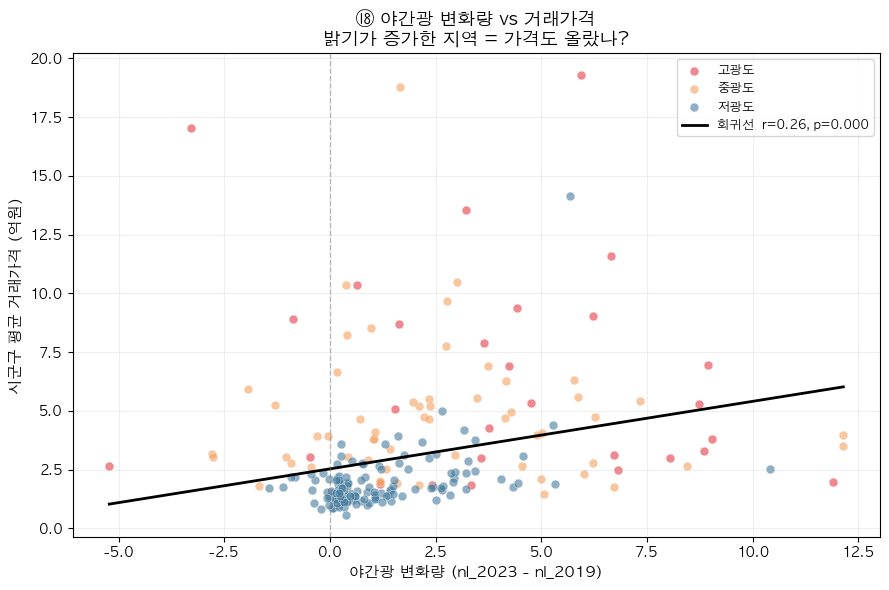

In [25]:
sgg_stat = df.groupby(['KOSIS_SGG_CODE','SGG_NM','cluster_name']).agg(
    거래건수 =(TARGET,'count'),
    평균가격 =(TARGET,'mean'),
    야간광   =('nightlight_avg','first'),
    고령화율 =('고령화율','mean'),
    nl_2019  =('nl_2019','first'),
    nl_2023  =('nl_2023','first'),
).reset_index()
sgg_stat['nl_change']   = sgg_stat['nl_2023'] - sgg_stat['nl_2019']
sgg_stat['평균가격_억'] = sgg_stat['평균가격'] / 10000

fig, ax = plt.subplots(figsize=(9, 6))
for cluster in CLUSTER_ORDER:
    sub = sgg_stat[sgg_stat['cluster_name'] == cluster]
    ax.scatter(sub['nl_change'], sub['평균가격_억'],
               c=CLUSTER_COLOR[cluster], label=cluster, alpha=0.6, s=40,
               edgecolors='white', linewidth=0.4)

clean3 = sgg_stat[['nl_change','평균가격_억']].dropna()
sl3, ic3, r3, p3, _ = stats.linregress(clean3['nl_change'], clean3['평균가격_억'])
x3 = np.linspace(clean3['nl_change'].min(), clean3['nl_change'].max(), 200)
ax.plot(x3, sl3*x3+ic3, color='black', linewidth=2, label=f'회귀선  r={r3:.2f}, p={p3:.3f}')
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('야간광 변화량 (nl_2023 - nl_2019)', fontsize=11)
ax.set_ylabel('시군구 평균 거래가격 (억원)', fontsize=11)
ax.set_title('⑱ 야간광 변화량 vs 거래가격\n밝기가 증가한 지역 = 가격도 올랐나?', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig18_nl_change_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.5 버블 차트 — 야간광 × 거래가격 × 거래건수 (시군구 집계)

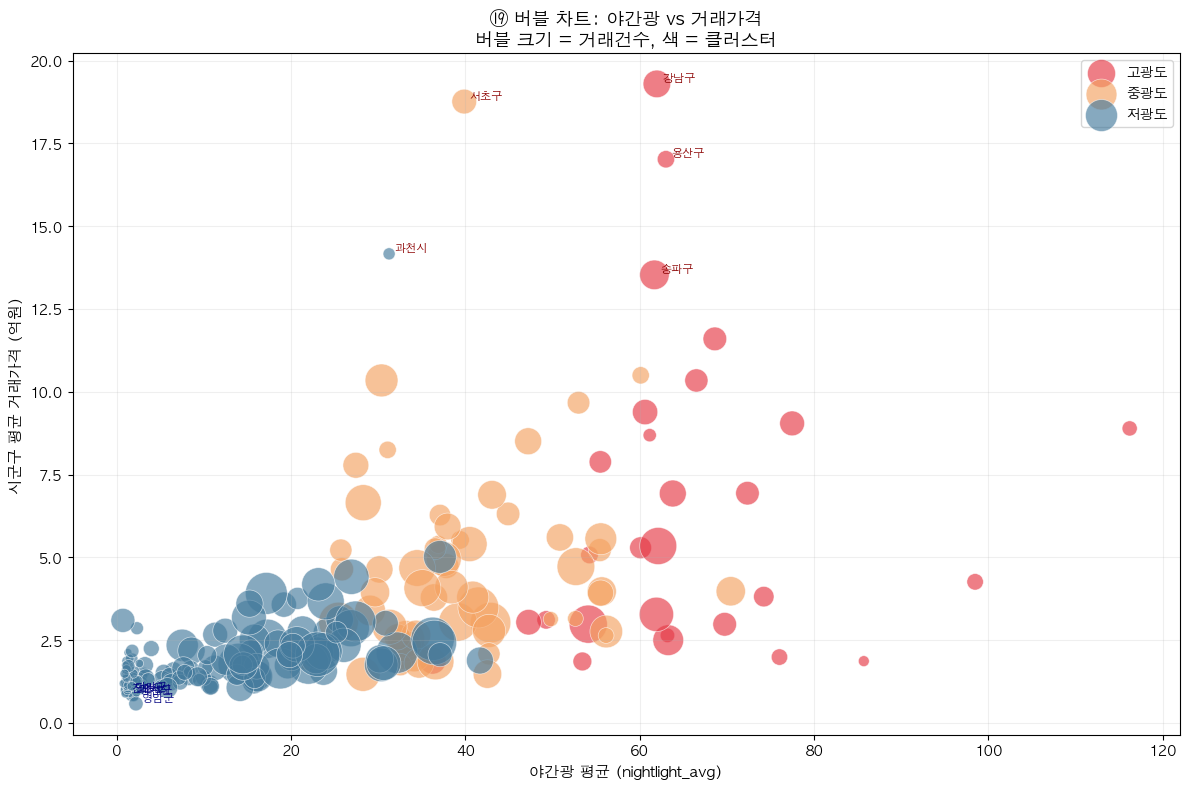

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))

for cluster in CLUSTER_ORDER:
    sub = sgg_stat[sgg_stat['cluster_name'] == cluster].dropna(subset=['고령화율'])
    ax.scatter(
        sub['야간광'], sub['평균가격_억'],
        s   = sub['거래건수'] / sgg_stat['거래건수'].max() * 1000 + 30,
        c   = CLUSTER_COLOR[cluster],
        alpha=0.65, label=cluster,
        edgecolors='white', linewidth=0.5
    )

# 가격 Top/Bottom 5 라벨
for _, row in sgg_stat.nlargest(5,'평균가격_억').iterrows():
    ax.annotate(row['SGG_NM'], (row['야간광'], row['평균가격_억']),
                fontsize=8, ha='left', xytext=(4,2), textcoords='offset points', color='darkred')
for _, row in sgg_stat.nsmallest(5,'평균가격_억').iterrows():
    ax.annotate(row['SGG_NM'], (row['야간광'], row['평균가격_억']),
                fontsize=8, ha='left', xytext=(4,2), textcoords='offset points', color='navy')

ax.set_xlabel('야간광 평균 (nightlight_avg)', fontsize=11)
ax.set_ylabel('시군구 평균 거래가격 (억원)', fontsize=11)
ax.set_title('⑲ 버블 차트: 야간광 vs 거래가격\n버블 크기 = 거래건수, 색 = 클러스터', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig19_bubble_nightlight_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.6 클러스터 간 가격 차이 — Kruskal-Wallis 통계 검정

In [27]:
groups = [df.loc[df['cluster_name']==c, TARGET].dropna() for c in CLUSTER_ORDER]
stat, pval = kruskal(*groups)

print('=== Kruskal-Wallis 검정 (클러스터 간 가격 차이) ===')
print(f'H = {stat:.2f},  p = {pval:.2e}')
print('→ p < 0.05 이면 클러스터별 가격 분포가 통계적으로 유의하게 다름')
print('\n클러스터별 중앙값:')
for c, g in zip(CLUSTER_ORDER, groups):
    print(f'  {c}: {g.median()/10000:.2f}억  (n={len(g):,})')

=== Kruskal-Wallis 검정 (클러스터 간 가격 차이) ===
H = 417014.12,  p = 0.00e+00
→ p < 0.05 이면 클러스터별 가격 분포가 통계적으로 유의하게 다름

클러스터별 중앙값:
  고광도: 4.48억  (n=273,943)
  중광도: 3.40억  (n=869,528)
  저광도: 1.95억  (n=1,253,359)


---

# 7. 커스텀 피처 상관계수 종합 비교

**우리가 merge한 피처들이 일반 건물 피처 대비 얼마나 유의미한지 한눈에 비교.**

## 7.1 전체 피처 상관계수 종합 순위

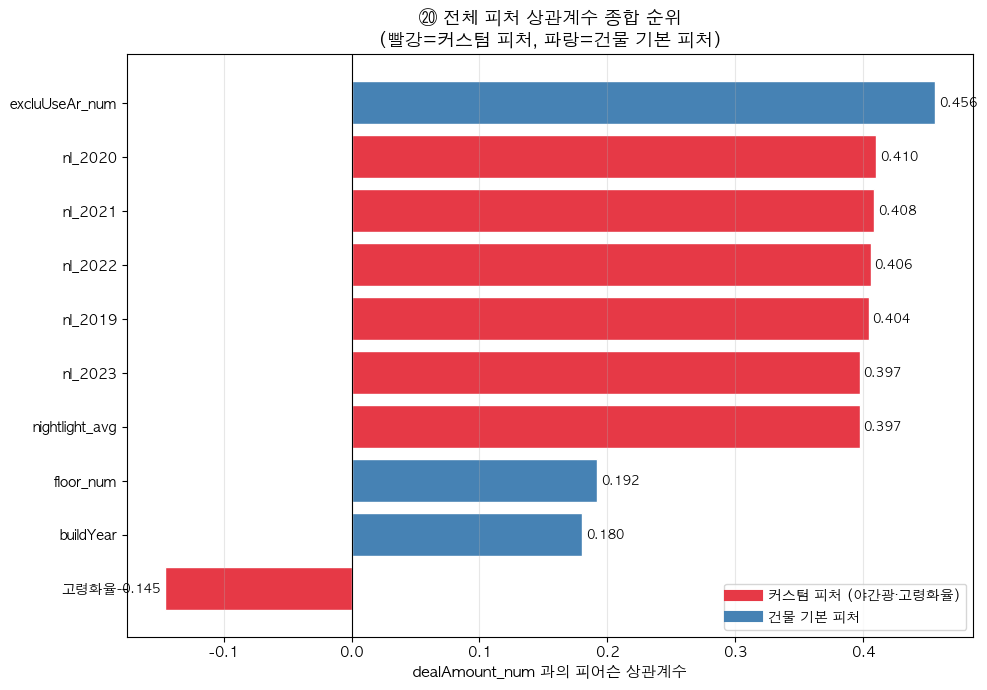

In [28]:
all_feat_cols = ['excluUseAr_num', 'floor_num', 'buildYear',
                 'nightlight_avg', '고령화율',
                 'nl_2019', 'nl_2020', 'nl_2021', 'nl_2022', 'nl_2023']

corr_all = df[all_feat_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

# 피처 분류 색상
custom_feats = {'nightlight_avg','고령화율','nl_2019','nl_2020','nl_2021','nl_2022','nl_2023'}
bar_colors = ['#e63946' if f in custom_feats else 'steelblue' for f in corr_all.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(corr_all.index, corr_all.values, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_all.values):
    offset = 0.003 if val >= 0 else -0.003
    ax.text(val+offset, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

legend_els = [
    Line2D([0],[0], color='#e63946', linewidth=8, label='커스텀 피처 (야간광·고령화율)'),
    Line2D([0],[0], color='steelblue', linewidth=8, label='건물 기본 피처'),
]
ax.legend(handles=legend_els, fontsize=10)
ax.set_xlabel('dealAmount_num 과의 피어슨 상관계수', fontsize=11)
ax.set_title('⑳ 전체 피처 상관계수 종합 순위\n(빨강=커스텀 피처, 파랑=건물 기본 피처)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig20_all_feature_corr_rank.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.2 피처 그룹별 설명력 비교 요약

In [29]:
print('='*50)
print('피처 그룹별 dealAmount_num 상관계수 요약')
print('='*50)

groups_info = {
    '건물 기본 피처': ['excluUseAr_num', 'floor_num', 'buildYear'],
    '야간광 (커스텀)': ['nightlight_avg', 'nl_2019','nl_2020','nl_2021','nl_2022','nl_2023'],
    '고령화율 (커스텀)': ['고령화율'],
}

for group, cols in groups_info.items():
    vals = corr_all[cols].abs()
    print(f'\n[{group}]')
    for col in cols:
        if col in corr_all:
            print(f'  {col:20s}: r={corr_all[col]:+.3f}  (|r|={abs(corr_all[col]):.3f})')

피처 그룹별 dealAmount_num 상관계수 요약

[건물 기본 피처]
  excluUseAr_num      : r=+0.456  (|r|=0.456)
  floor_num           : r=+0.192  (|r|=0.192)
  buildYear           : r=+0.180  (|r|=0.180)

[야간광 (커스텀)]
  nightlight_avg      : r=+0.397  (|r|=0.397)
  nl_2019             : r=+0.404  (|r|=0.404)
  nl_2020             : r=+0.410  (|r|=0.410)
  nl_2021             : r=+0.408  (|r|=0.408)
  nl_2022             : r=+0.406  (|r|=0.406)
  nl_2023             : r=+0.397  (|r|=0.397)

[고령화율 (커스텀)]
  고령화율                : r=-0.145  (|r|=0.145)


---

# 종합 요약

| 파트 | 번호 | 시각화 | 핵심 메시지 |
|------|:----:|--------|-------------|
| 1. 타겟 분포 | ① | 히스토그램 (원본 + log) | 우편향 → log 변환 검토 |
| 1. 타겟 분포 | ② | 클러스터별 거래건수·가격 | **저광도 = 거래 적고 싸다** |
| 2. 수치 상관 | ③ | 전체 상관계수 히트맵 | 피처 간 관계 한눈에 |
| 2. 수치 상관 | ④ | 상관계수 순위 바 차트 | 어떤 피처가 중요한지 |
| 3. 시간 변수 | ⑤ | 연도별 가격 추이 (전체+클러스터) | 2021~2022 급등 후 하락 |
| 3. 시간 변수 | ⑥ | 월별 가격·거래건수 | 계절성 패턴 확인 |
| 3. 시간 변수 | ⑦ | 연도×클러스터 히트맵 | 클러스터별 가격 추이 비교 |
| 4. 건물 피처 | ⑧ | 전용면적 산점도 + 구간 박스 | **면적이 가격 예측 핵심 피처** |
| 4. 건물 피처 | ⑨ | 층수 산점도 + 구간 바 | 높을수록 비싼 경향 |
| 4. 건물 피처 | ⑩ | 건축연도 산점도 + 연도별 추이 | 신축일수록 비쌈 |
| 4. 건물 피처 | ⑪ | 건물 3종 한눈에 비교 | 클러스터별 패턴 차이 |
| 4. 건물 피처 | ⑫ | 클러스터별 박스플롯 | 고광도 > 중광도 > 저광도 |
| 5. 범주형 | ⑬ | 임차권 유형별 가격 | 유형별 차이 확인 |
| 5. 범주형 | ⑭ | 시군구별 Top/Bottom 20 | 지역격차 시각화 |
| 6. 커스텀 피처 | ⑮ | 야간광 vs 가격 산점도 | **밝을수록 비쌈** |
| 6. 커스텀 피처 | ⑯ | 고령화율 vs 가격 산점도 | **고령화↑ 가격↓** |
| 6. 커스텀 피처 | ⑰ | 연도별 야간광 5종 vs 가격 | 연도별 일관성 확인 |
| 6. 커스텀 피처 | ⑱ | 야간광 변화량 vs 가격 | nl_change 피처 유의성 |
| 6. 커스텀 피처 | ⑲ | 버블 차트 (시군구 집계) | 삼관관계 종합 시각화 |
| 6. 커스텀 피처 | ⑳(검정) | Kruskal-Wallis | 클러스터 차이 통계적 유의성 |
| 7. 종합 비교 | ⑳ | 전체 피처 상관계수 순위 | **커스텀 피처가 의미 있음을 입증** |